<a href="https://colab.research.google.com/github/vaishnavivijesh9-boop/Employee-attrition-analysis/blob/main/python/attrition_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1470, 35)
Attrition
No     1233
Yes     237
Name: count, dtype: int64
(1176, 22)
(294, 22)
AttritionFlag
0    986
1    190
Name: count, dtype: int64
AttritionFlag
0    247
1     47
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7414965986394558

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.76      0.83       247
           1       0.34      0.66      0.45        47

    accuracy                           0.74       294
   macro avg       0.63      0.71      0.64       294
weighted avg       0.83      0.74      0.77       294


Confusion Matrix:
[[187  60]
 [ 16  31]]
Accuracy: 0.8027210884353742

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       247
           1       0.42      0.57      0.48        47

    accuracy                           0.80       294
   macro avg       0.66      0.71      0.68       294
weighted avg       0.83      0.80      0.81       294


Confusion Matrix:
[[209  38]
 [ 20  27]]
Accuracy: 0.7108843537414966

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81     

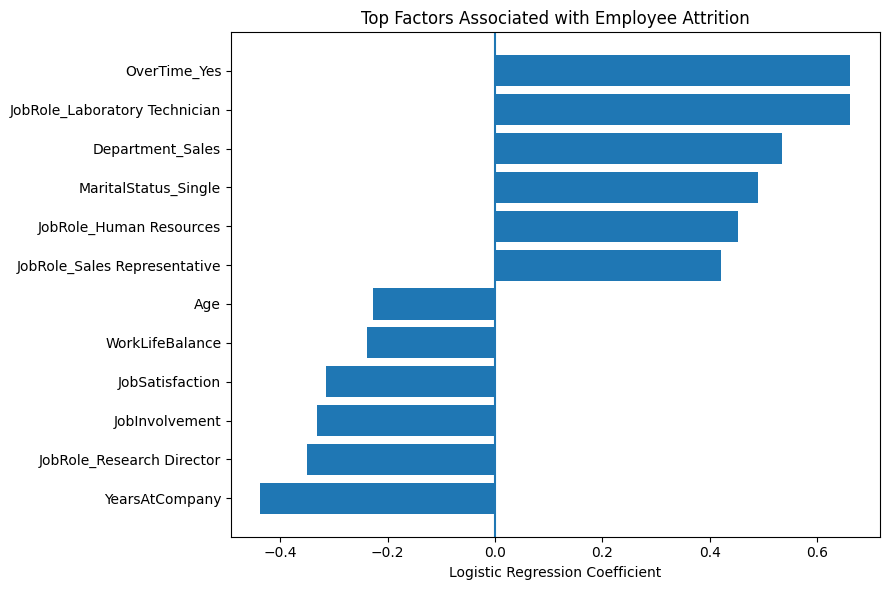

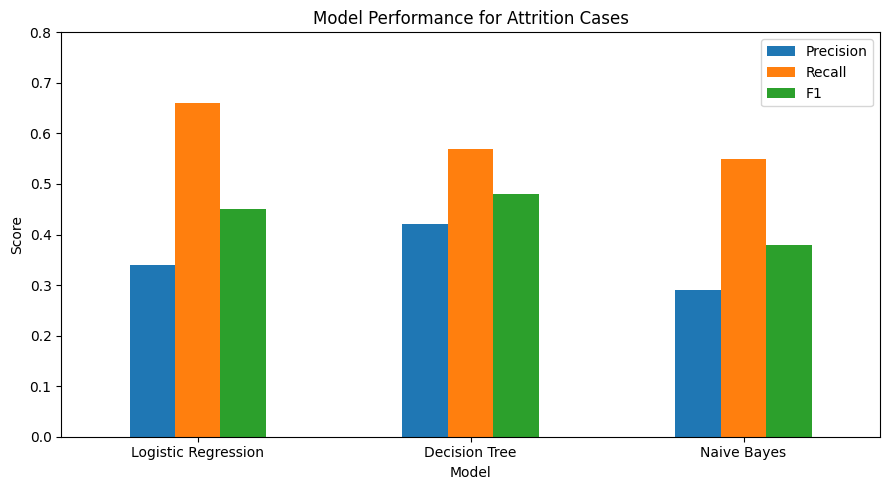

In [22]:
import pandas as pd
df = pd.read_csv("employee_attrition_cleaned.csv")

df.head()
print(df.shape)
print(df["Attrition"].value_counts())
df["AttritionFlag"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

df[["Attrition", "AttritionFlag"]].head()
features = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "JobInvolvement",
    "JobSatisfaction",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
    "OverTime",
    "Department",
    "JobRole",
    "MaritalStatus"
]

X = df[features]
y = df["AttritionFlag"]
X = pd.get_dummies(X, drop_first=True)

X.head()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    )
)

model.fit(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

tree_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=4
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_predictions))
print("\nClassification Report:")
print(classification_report(y_test, tree_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_predictions))

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_predictions))
print("\nClassification Report:")
print(classification_report(y_test, nb_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_predictions))
import pandas as pd

logistic_model = model.named_steps["logisticregression"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

import matplotlib.pyplot as plt

top_factors = pd.concat([
    coefficients.head(6),
    coefficients.tail(6)
])

top_factors = top_factors.sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top_factors["Feature"], top_factors["Coefficient"])
plt.axvline(0)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Top Factors Associated with Employee Attrition")
plt.tight_layout()
plt.show()
import pandas as pd
import matplotlib.pyplot as plt

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes"
    ],
    "Accuracy": [0.741, 0.803, 0.711],
    "Precision": [0.34, 0.42, 0.29],
    "Recall": [0.66, 0.57, 0.55],
    "F1": [0.45, 0.48, 0.38]
})

model_results
model_results.set_index("Model")[["Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance for Attrition Cases")
plt.ylabel("Score")
plt.ylim(0, 0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()